In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
#import seaborn as sns

In [14]:
movies = pd.read_csv(
    "../data/movies.dat",
    sep="::",
    engine="python",
    encoding="latin-1",
    names=["movie_id", "title", "genres"]
)

ratings = pd.read_csv(
    "../data/ratings.dat",
    sep="::",
    engine="python",
    encoding="latin-1",
    names=["user_id", "movie_id", "rating", "timestamp"]
)

users = pd.read_csv(
    "../data/users.dat",
    sep="::",
    engine="python",
    encoding="latin-1",
    names=["user_id", "gender", "age", "occupation", "zip_code"]
)

In [16]:
movies.head()


,movie_id,title,genres
0,1,Toy Story (1995),Animation|Children's|Comedy
1,2,Jumanji (1995),Adventure|Children's|Fantasy
2,3,Grumpier Old Men (1995),Comedy|Romance
3,4,Waiting to Exhale (1995),Comedy|Drama
4,5,Father of the Bride Part II (1995),Comedy


In [18]:
movies.shape


(3883, 3)

In [17]:
ratings.head()


,user_id,movie_id,rating,timestamp
0,1,1193,5,978300760
1,1,661,3,978302109
2,1,914,3,978301968
3,1,3408,4,978300275
4,1,2355,5,978824291


In [19]:
ratings.shape


(1000209, 4)

In [20]:
ratings["rating"].describe()


count    1.000209e+06
mean     3.581564e+00
std      1.117102e+00
min      1.000000e+00
25%      3.000000e+00
50%      4.000000e+00
75%      4.000000e+00
max      5.000000e+00
Name: rating, dtype: float64

In [21]:
ratings["movie_id"].nunique()


3706

In [22]:

ratings["user_id"].nunique()

6040

6040 user had reviewed movies

How many genres exist?

In [23]:
all_genres = (
    movies["genres"]
    .str.split("|")
    .explode()
    .unique()
)

len(all_genres), all_genres

(18,
 <StringArray>
 [  'Animation',  'Children's',      'Comedy',   'Adventure',     'Fantasy',
      'Romance',       'Drama',      'Action',       'Crime',    'Thriller',
       'Horror',      'Sci-Fi', 'Documentary',         'War',     'Musical',
      'Mystery',   'Film-Noir',     'Western']
 Length: 18, dtype: str)

How many ratings does each movie have?

In [25]:
ratings_per_movie = ratings.groupby("movie_id").size()
ratings_per_movie

movie_id
1       2077
2        701
3        478
4        170
5        296
        ... 
3948     862
3949     304
3950      54
3951      40
3952     388
Length: 3706, dtype: int64

How many ratings does each user have?

In [26]:
ratings_per_user = ratings.groupby("user_id").size()
ratings_per_user

user_id
1        53
2       129
3        51
4        21
5       198
       ... 
6036    888
6037    202
6038     20
6039    123
6040    341
Length: 6040, dtype: int64

most reviewed movies

Users: 6,040
Movies: 3,883
Ratings: 1,000,209

Rating distribution:


,rating,count
0,1,56174
1,2,107557
2,3,261197
3,4,348971
4,5,226310


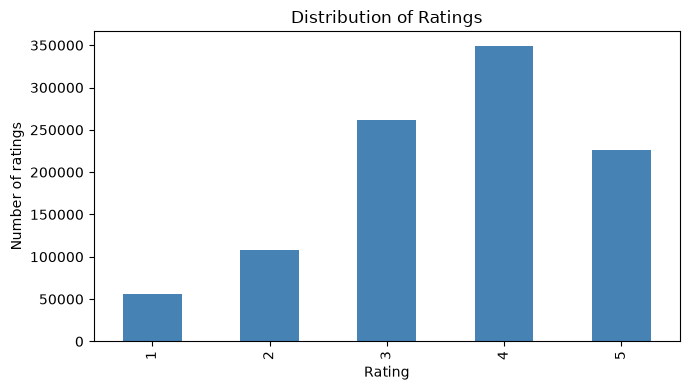


Top 10 most-rated movies:


,movie_id,rating_count,title
2651,2858,3428,American Beauty (1999)
253,260,2991,Star Wars: Episode IV - A New Hope (1977)
1106,1196,2990,Star Wars: Episode V - The Empire Strikes Back...
1120,1210,2883,Star Wars: Episode VI - Return of the Jedi (1983)
466,480,2672,Jurassic Park (1993)
1848,2028,2653,Saving Private Ryan (1998)
575,589,2649,Terminator 2: Judgment Day (1991)
2374,2571,2590,"Matrix, The (1999)"
1178,1270,2583,Back to the Future (1985)
579,593,2578,"Silence of the Lambs, The (1991)"



Possible user-movie pairs: 23,453,320
Observed user-movie pairs: 1,000,209
Matrix density: 4.2647%
Matrix sparsity: 95.7353%

Most common genres:


,genre,movie_count
0,Drama,1603
1,Comedy,1200
2,Action,503
3,Thriller,492
4,Romance,471
5,Horror,343
6,Adventure,283
7,Sci-Fi,276
8,Children's,251
9,Crime,211


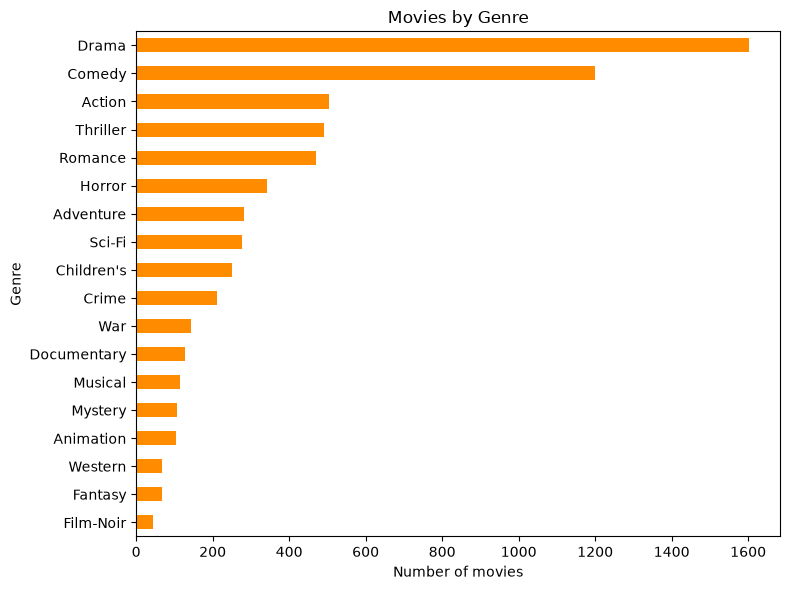


Movies with multiple genres: 1,858
Share of movies with multiple genres: 47.85%


number_of_genres
1    2025
2    1322
3     421
4     100
5      14
6       1
Name: movie_count, dtype: int64

In [28]:
# Dataset overview
n_users = users["user_id"].nunique()
n_movies = movies["movie_id"].nunique()
n_ratings = len(ratings)

print(f"Users: {n_users:,}")
print(f"Movies: {n_movies:,}")
print(f"Ratings: {n_ratings:,}")

# Distribution of ratings
rating_distribution = (
    ratings["rating"]
    .value_counts()
    .sort_index()
    .rename_axis("rating")
    .reset_index(name="count")
)
print("\nRating distribution:")
display(rating_distribution)

ax = rating_distribution.plot.bar(
    x="rating",
    y="count",
    legend=False,
    figsize=(7, 4),
    color="steelblue",
    title="Distribution of Ratings"
)
ax.set_xlabel("Rating")
ax.set_ylabel("Number of ratings")
plt.tight_layout()
plt.show()

# Movies with the most ratings
movie_rating_counts = (
    ratings.groupby("movie_id")
    .size()
    .rename("rating_count")
    .reset_index()
    .merge(movies[["movie_id", "title"]], on="movie_id", how="left")
    .sort_values("rating_count", ascending=False)
)
print("\nTop 10 most-rated movies:")
display(movie_rating_counts.head(10))

# User-movie matrix sparsity
possible_ratings = n_users * n_movies
observed_ratings = ratings[["user_id", "movie_id"]].drop_duplicates().shape[0]
density = observed_ratings / possible_ratings
sparsity = 1 - density
print(f"\nPossible user-movie pairs: {possible_ratings:,}")
print(f"Observed user-movie pairs: {observed_ratings:,}")
print(f"Matrix density: {density:.4%}")
print(f"Matrix sparsity: {sparsity:.4%}")

# Most common genres
genre_counts = (
    movies.assign(genre=movies["genres"].str.split("|"))
    .explode("genre")["genre"]
    .value_counts()
    .rename_axis("genre")
    .reset_index(name="movie_count")
)
print("\nMost common genres:")
display(genre_counts)

ax = genre_counts.sort_values("movie_count").plot.barh(
    x="genre",
    y="movie_count",
    legend=False,
    figsize=(8, 6),
    color="darkorange",
    title="Movies by Genre"
)
ax.set_xlabel("Number of movies")
ax.set_ylabel("Genre")
plt.tight_layout()
plt.show()

# Movies with multiple genres
movies["genre_count"] = movies["genres"].str.split("|").str.len()
multiple_genre_movies = (movies["genre_count"] > 1).sum()
multiple_genre_share = multiple_genre_movies / n_movies
print(f"\nMovies with multiple genres: {multiple_genre_movies:,}")
print(f"Share of movies with multiple genres: {multiple_genre_share:.2%}")

movies["genre_count"].value_counts().sort_index().rename_axis("number_of_genres").rename("movie_count")